In [2]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import os
from sklearn.mixture import GaussianMixture

# Carichiamo il preprocessing
with open("preprocessing.pkl", "rb") as f:
    prep = pickle.load(f)

X_train = prep["X_train"]
DATA_PATH = "NuclearPowerPlantAccidentData/Operation_csv_data"
conditions = sorted(os.listdir(DATA_PATH))

print(f"X_train shape: {X_train.shape}")

X_train shape: (202, 6)


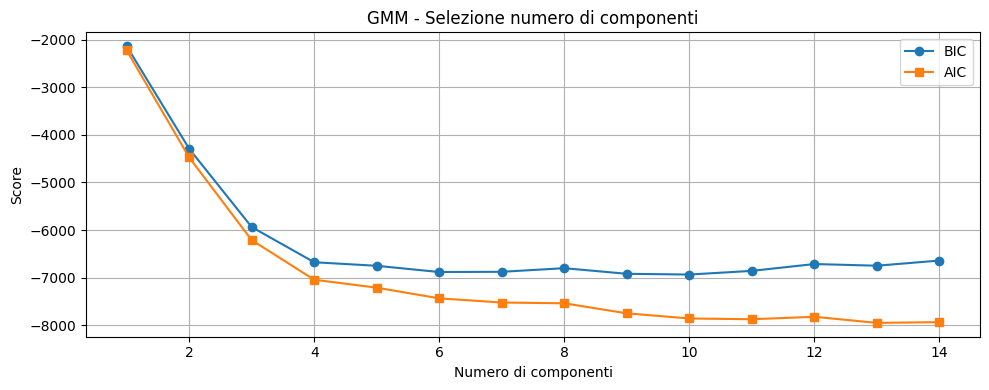

Numero ottimale di componenti (BIC): 10


In [3]:
# Selezione numero di componenti via BIC
bic_scores = []
aic_scores = []
n_components_range = range(1, 15)

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42, n_init=5)
    gmm.fit(X_train)
    bic_scores.append(gmm.bic(X_train))
    aic_scores.append(gmm.aic(X_train))

plt.figure(figsize=(10, 4))
plt.plot(n_components_range, bic_scores, marker='o', label='BIC')
plt.plot(n_components_range, aic_scores, marker='s', label='AIC')
plt.xlabel("Numero di componenti")
plt.ylabel("Score")
plt.title("GMM - Selezione numero di componenti")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_n = np.argmin(bic_scores) + 1
print(f"Numero ottimale di componenti (BIC): {best_n}")

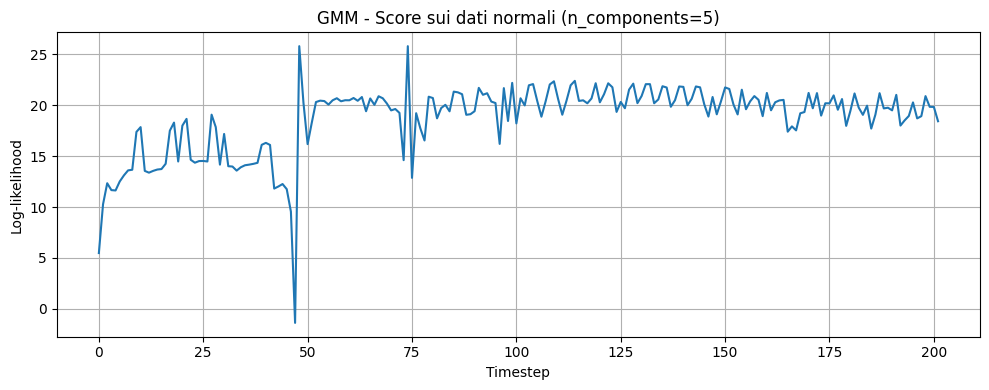

Score medio: 18.679
Score min:   -1.382
Score max:   25.811


In [4]:
# Addestriamo GMM con 5 componenti
n_components = 5
gmm = GaussianMixture(n_components=n_components, random_state=42, n_init=10)
gmm.fit(X_train)

# Log-likelihood sui dati di training
scores_train_gmm = gmm.score_samples(X_train)

plt.figure(figsize=(10, 4))
plt.plot(scores_train_gmm)
plt.xlabel("Timestep")
plt.ylabel("Log-likelihood")
plt.title(f"GMM - Score sui dati normali (n_components={n_components})")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Score medio: {scores_train_gmm.mean():.3f}")
print(f"Score min:   {scores_train_gmm.min():.3f}")
print(f"Score max:   {scores_train_gmm.max():.3f}")

Soglia (percentile 5): 12.350


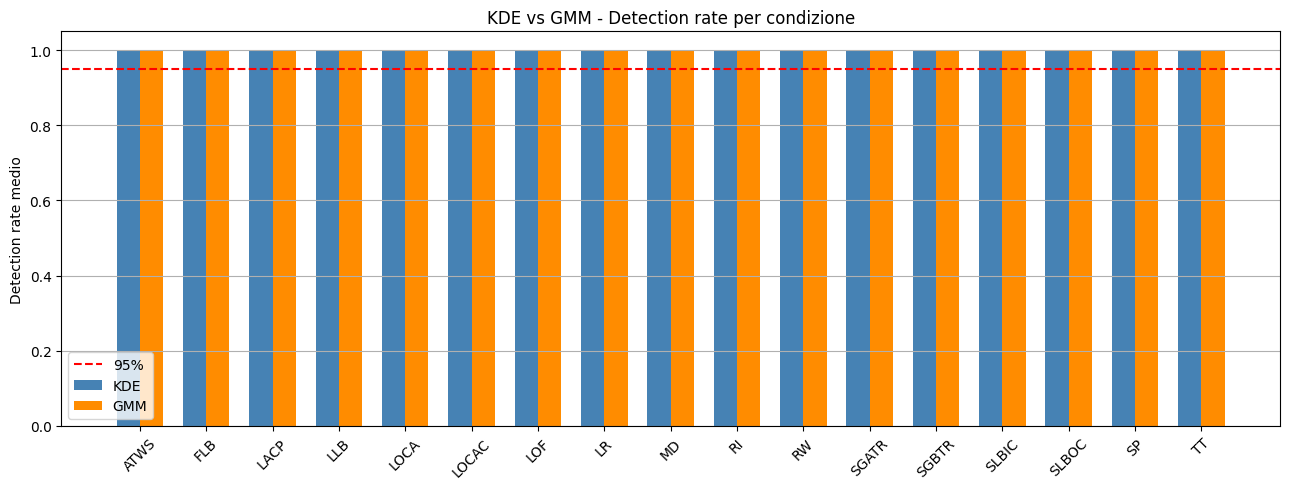

ATWS       100.0%
FLB        100.0%
LACP       100.0%
LLB        100.0%
LOCA       100.0%
LOCAC      100.0%
LOF        100.0%
LR         100.0%
MD         100.0%
RI         100.0%
RW         100.0%
SGATR      100.0%
SGBTR      100.0%
SLBIC      100.0%
SLBOC      100.0%
SP         100.0%
TT         100.0%


In [5]:
# Soglia: percentile 5
threshold_gmm = np.percentile(scores_train_gmm, 5)
print(f"Soglia (percentile 5): {threshold_gmm:.3f}")

# Funzione di scoring
def compute_anomaly_score_gmm(df, prep, gmm):
    X = df[prep["features_kept"]].values
    X_scaled = prep["scaler"].transform(X)
    X_pca = prep["pca"].transform(X_scaled)
    return gmm.score_samples(X_pca)

# Test su tutte le condizioni
results_gmm = {}
for cond in conditions:
    if cond == "Normal":
        continue
    cond_path = os.path.join(DATA_PATH, cond)
    files = os.listdir(cond_path)
    detected = []
    for f in files:
        df = pd.read_csv(os.path.join(cond_path, f))
        scores = compute_anomaly_score_gmm(df, prep, gmm)
        detected.append((scores < threshold_gmm).mean())
    results_gmm[cond] = np.mean(detected)

# Confronto KDE vs GMM
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(results_gmm))
width = 0.35
ax.bar(x - width/2, prep.get("kde_results", {cond: 1.0 for cond in results_gmm}).values(), 
       width, label="KDE", color="steelblue")
ax.bar(x + width/2, results_gmm.values(), width, label="GMM", color="darkorange")
ax.axhline(y=0.95, color="red", linestyle="--", label="95%")
ax.set_xticks(x)
ax.set_xticklabels(results_gmm.keys(), rotation=45)
ax.set_ylabel("Detection rate medio")
ax.set_title("KDE vs GMM - Detection rate per condizione")
ax.legend()
ax.grid(axis="y")
plt.tight_layout()
plt.show()

for cond, rate in results_gmm.items():
    print(f"{cond:<10} {rate*100:.1f}%")

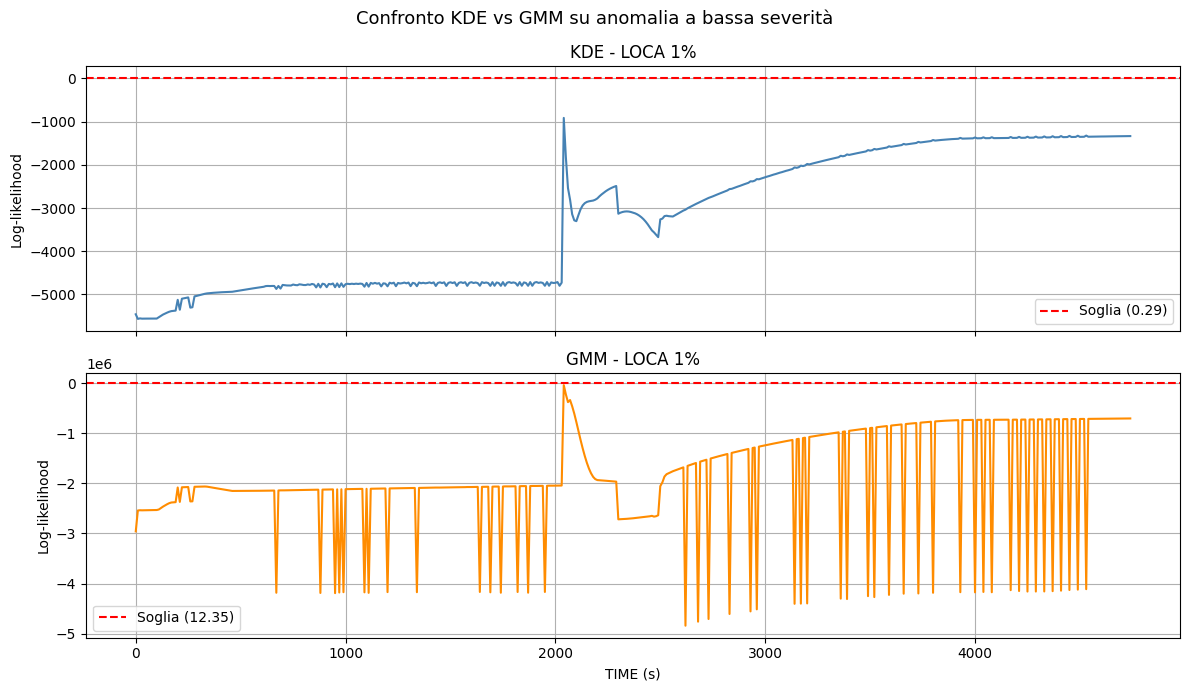

KDE detection rate LOCA 1%: 100.0%
GMM detection rate LOCA 1%: 100.0%


In [6]:
df_loca_1 = pd.read_csv(os.path.join(DATA_PATH, "LOCA", "1.csv"))

scores_kde_1 = prep["kde"].score_samples(
    prep["pca"].transform(prep["scaler"].transform(df_loca_1[prep["features_kept"]].values))
)
scores_gmm_1 = compute_anomaly_score_gmm(df_loca_1, prep, gmm)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(df_loca_1["TIME"], scores_kde_1, color="steelblue")
axes[0].axhline(y=prep["threshold"], color="red", linestyle="--", label=f"Soglia ({prep['threshold']:.2f})")
axes[0].set_title("KDE - LOCA 1%")
axes[0].set_ylabel("Log-likelihood")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(df_loca_1["TIME"], scores_gmm_1, color="darkorange")
axes[1].axhline(y=threshold_gmm, color="red", linestyle="--", label=f"Soglia ({threshold_gmm:.2f})")
axes[1].set_title("GMM - LOCA 1%")
axes[1].set_ylabel("Log-likelihood")
axes[1].set_xlabel("TIME (s)")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Confronto KDE vs GMM su anomalia a bassa severità", fontsize=13)
plt.tight_layout()
plt.show()

print(f"KDE detection rate LOCA 1%: {(scores_kde_1 < prep['threshold']).mean()*100:.1f}%")
print(f"GMM detection rate LOCA 1%: {(scores_gmm_1 < threshold_gmm).mean()*100:.1f}%")

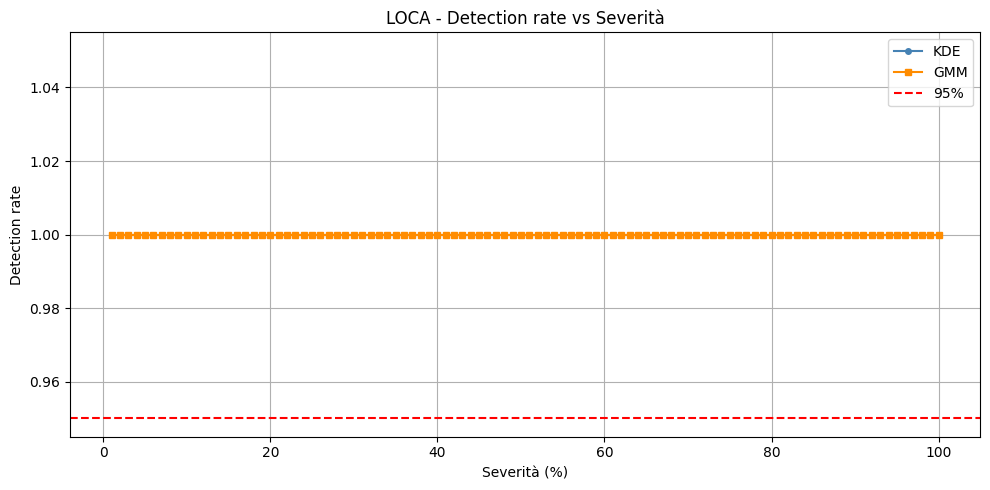

In [7]:
# Detection rate vs severità per LOCA
loca_files = sorted(os.listdir(os.path.join(DATA_PATH, "LOCA")), 
                    key=lambda x: int(x.replace(".csv", "")))

severities = []
dr_kde = []
dr_gmm = []

for f in loca_files:
    severity = int(f.replace(".csv", ""))
    df = pd.read_csv(os.path.join(DATA_PATH, "LOCA", f))
    
    scores_kde = prep["kde"].score_samples(
        prep["pca"].transform(prep["scaler"].transform(df[prep["features_kept"]].values))
    )
    scores_gmm = compute_anomaly_score_gmm(df, prep, gmm)
    
    severities.append(severity)
    dr_kde.append((scores_kde < prep["threshold"]).mean())
    dr_gmm.append((scores_gmm < threshold_gmm).mean())

plt.figure(figsize=(10, 5))
plt.plot(severities, dr_kde, marker='o', markersize=4, label="KDE", color="steelblue")
plt.plot(severities, dr_gmm, marker='s', markersize=4, label="GMM", color="darkorange")
plt.axhline(y=0.95, color="red", linestyle="--", label="95%")
plt.xlabel("Severità (%)")
plt.ylabel("Detection rate")
plt.title("LOCA - Detection rate vs Severità")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

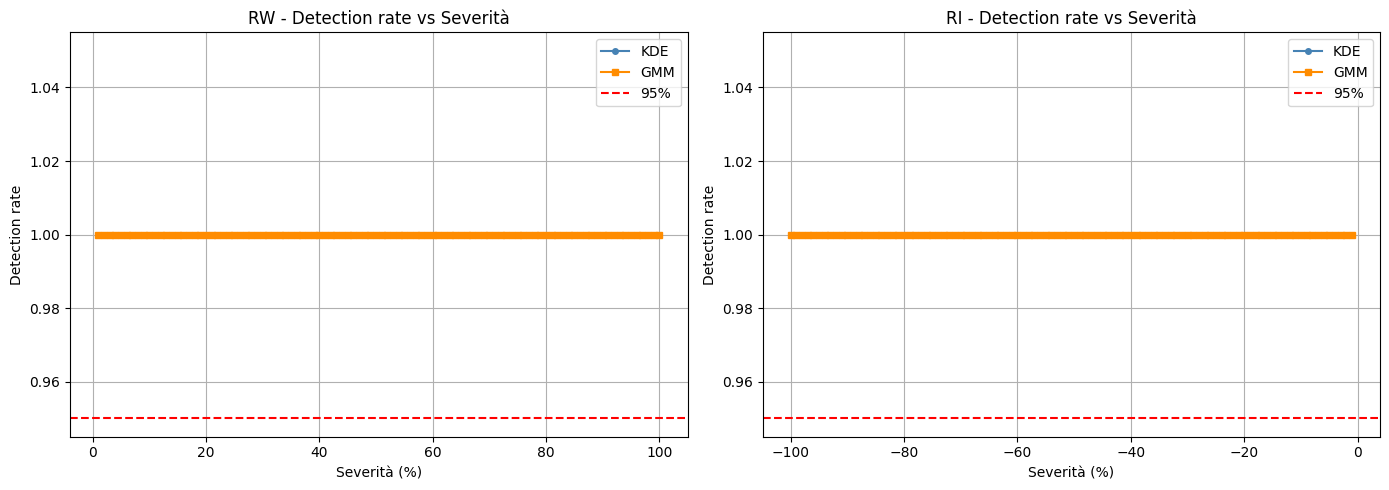

In [8]:
def detection_rate_vs_severity(condition, prep, gmm, threshold_gmm):
    cond_path = os.path.join(DATA_PATH, condition)
    files = sorted(os.listdir(cond_path), key=lambda x: int(x.replace(".csv", "")))
    
    severities, dr_kde, dr_gmm = [], [], []
    for f in files:
        severity = int(f.replace(".csv", ""))
        df = pd.read_csv(os.path.join(cond_path, f))
        
        scores_kde = prep["kde"].score_samples(
            prep["pca"].transform(prep["scaler"].transform(df[prep["features_kept"]].values))
        )
        scores_gmm = compute_anomaly_score_gmm(df, prep, gmm)
        
        severities.append(severity)
        dr_kde.append((scores_kde < prep["threshold"]).mean())
        dr_gmm.append((scores_gmm < threshold_gmm).mean())
    
    return severities, dr_kde, dr_gmm

# Proviamo RW e RI che sono perturbazioni graduali
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cond in zip(axes, ["RW", "RI"]):
    sev, kde_r, gmm_r = detection_rate_vs_severity(cond, prep, gmm, threshold_gmm)
    ax.plot(sev, kde_r, marker='o', markersize=4, label="KDE", color="steelblue")
    ax.plot(sev, gmm_r, marker='s', markersize=4, label="GMM", color="darkorange")
    ax.axhline(y=0.95, color="red", linestyle="--", label="95%")
    ax.set_xlabel("Severità (%)")
    ax.set_ylabel("Detection rate")
    ax.set_title(f"{cond} - Detection rate vs Severità")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [14]:
for cond in multi_severity:
    files = os.listdir(os.path.join(DATA_PATH, cond))
    print(f"{cond:<10} {sorted(files)[:5]} ... totale: {len(files)}")

FLB        ['1.csv', '10.csv', '100.csv', '11.csv', '12.csv'] ... totale: 100
LLB        ['1.csv', '10.csv', '100.csv', '101.csv', '11.csv'] ... totale: 101
LOCA       ['1.csv', '10.csv', '100.csv', '11.csv', '12.csv'] ... totale: 100
LOCAC      ['1.csv', '10.csv', '100.csv', '11.csv', '12.csv'] ... totale: 100
LR         ['1.csv', '10.csv', '11.csv', '12.csv', '13.csv'] ... totale: 99
MD         ['1.csv', '10.csv', '100.csv', '11.csv', '12.csv'] ... totale: 100
RI         ['-1.csv', '-10.csv', '-100.csv', '-11.csv', '-12.csv'] ... totale: 100
RW         ['1.csv', '10.csv', '100.csv', '11.csv', '12.csv'] ... totale: 100
SGATR      ['1.csv', '10.csv', '100.csv', '11.csv', '12.csv'] ... totale: 100
SGBTR      ['1.csv', '10.csv', '100.csv', '101.csv', '102.csv'] ... totale: 110
SLBIC      ['1.csv', '10.csv', '100.csv', '101.csv', '11.csv'] ... totale: 101
SLBOC      ['1.csv', '10.csv', '100.csv', '11.csv', '12.csv'] ... totale: 100


In [16]:
def detection_rate_vs_severity(condition, prep, gmm, threshold_gmm):
    cond_path = os.path.join(DATA_PATH, condition)
    files = os.listdir(cond_path)
    
    # Sorting corretto che gestisce anche i negativi
    files = sorted(files, key=lambda x: float(x.replace(".csv", "")))
    
    severities, dr_kde, dr_gmm = [], [], []
    for f in files:
        severity = float(f.replace(".csv", ""))
        df = pd.read_csv(os.path.join(cond_path, f))
        
        scores_kde = prep["kde"].score_samples(
            prep["pca"].transform(prep["scaler"].transform(df[prep["features_kept"]].values))
        )
        scores_gmm = compute_anomaly_score_gmm(df, prep, gmm)
        
        severities.append(severity)
        dr_kde.append((scores_kde < prep["threshold"]).mean())
        dr_gmm.append((scores_gmm < threshold_gmm).mean())
    
    return severities, dr_kde, dr_gmm

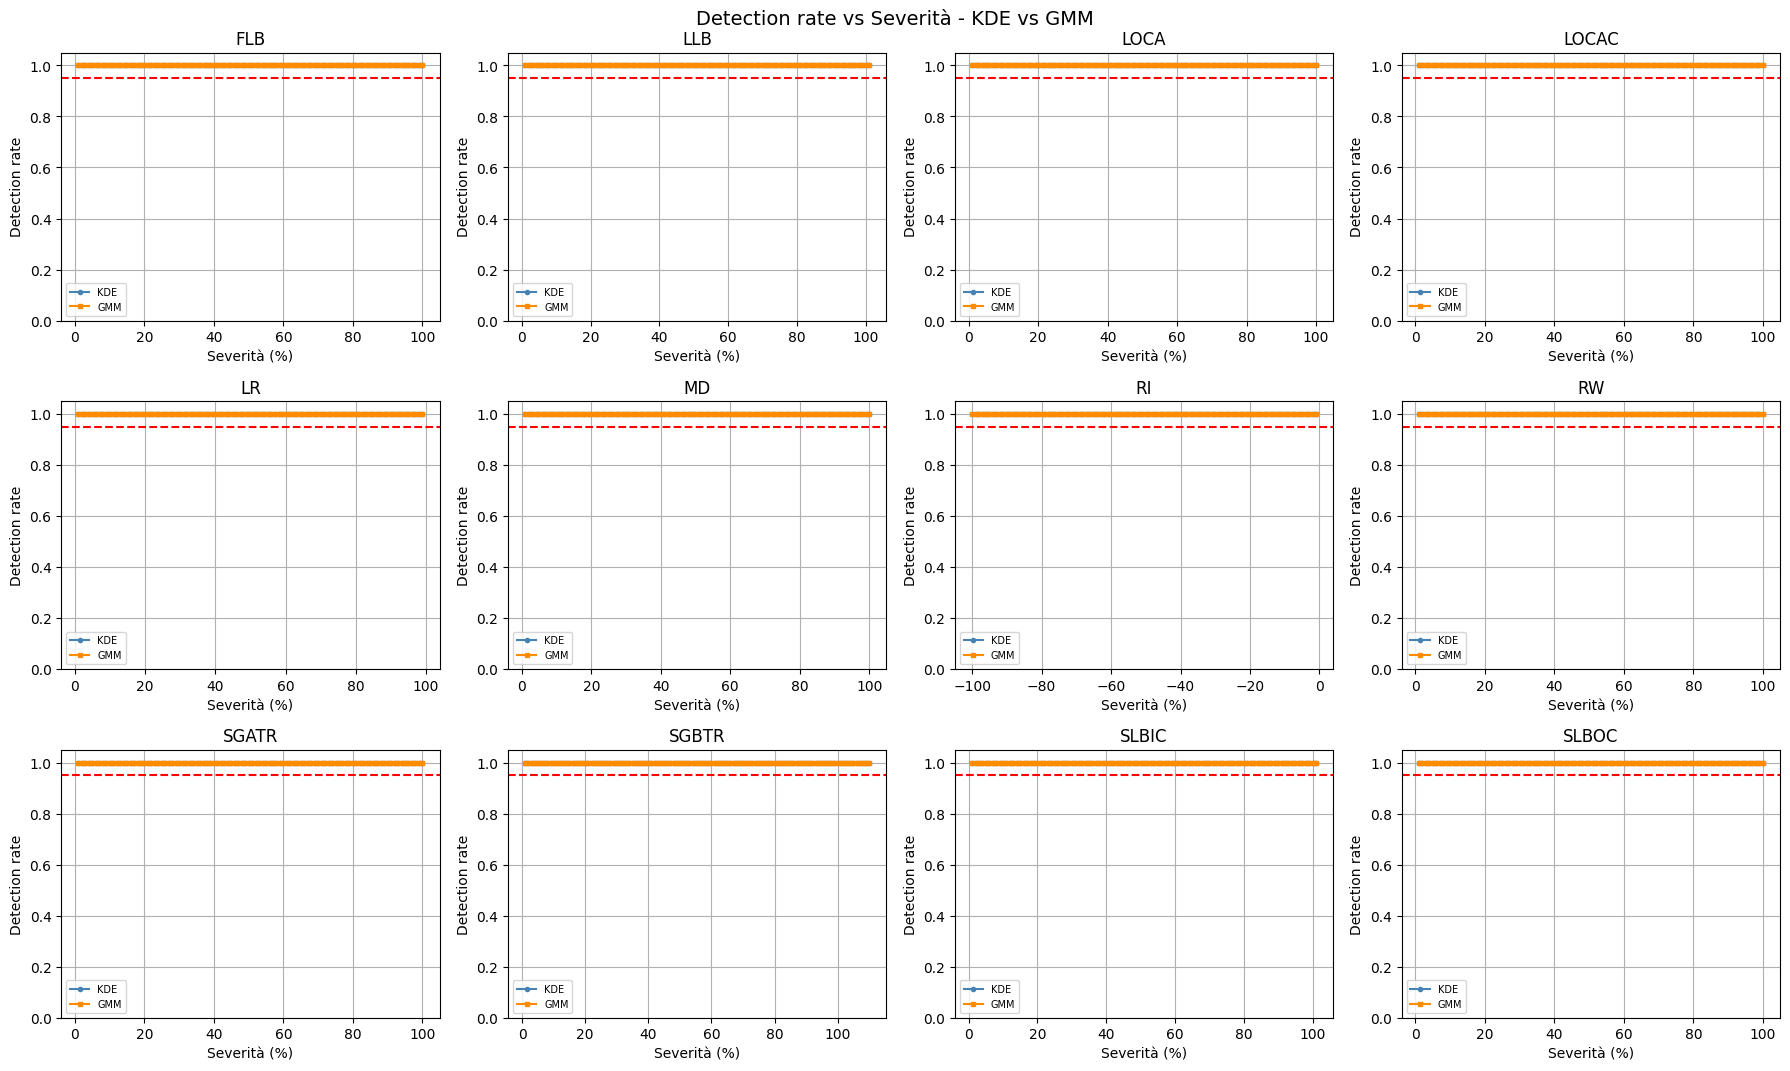

In [17]:
# Condizioni con più file di severità
multi_severity = [c for c in conditions if c != "Normal" and 
                  len(os.listdir(os.path.join(DATA_PATH, c))) > 1]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, cond in enumerate(multi_severity):
    try:
        sev, kde_r, gmm_r = detection_rate_vs_severity(cond, prep, gmm, threshold_gmm)
        axes[i].plot(sev, kde_r, marker='o', markersize=3, label="KDE", color="steelblue")
        axes[i].plot(sev, gmm_r, marker='s', markersize=3, label="GMM", color="darkorange")
        axes[i].axhline(y=0.95, color="red", linestyle="--")
        axes[i].set_title(cond)
        axes[i].set_xlabel("Severità (%)")
        axes[i].set_ylabel("Detection rate")
        axes[i].set_ylim(0, 1.05)
        axes[i].legend(fontsize=7)
        axes[i].grid(True)
    except Exception as e:
        axes[i].set_title(f"{cond} - errore")

# Nascondiamo gli assi vuoti
for j in range(len(multi_severity), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Detection rate vs Severità - KDE vs GMM", fontsize=14)
plt.tight_layout()
plt.show()